# BUSINESS PROBLEM

# The bank has been experiencing fraud accident which is leading to financial loss in the  institution and eroding customers trust
# The current fraud detector response to a minority fraudulent transcations making the bank to identify them without advanced analytics
# i will use a machine leaarning classification models  like logistic regression,decision tree classifier
# if the recall of the model is above 0.8 the model performs better to detect credit card fraud

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Administrator\Downloads\archive(12)\creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.tail(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# DATA HANDLING
# the dataset has 284807 rows and 31 columns
# The   dataset  contains  31 variables
# due to confidentiality and sensitivity of customers details most of the original features have been transformed using principal component analysis
# The dataset contains numerical features which there are 30 float values and 1 interger

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
print(df.duplicated())

0         False
1         False
2         False
3         False
4         False
          ...  
284802    False
284803    False
284804    False
284805    False
284806    False
Length: 284807, dtype: bool


In [11]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


# DATA HANDLING
# The dataset does not cointain any null values and duplicated values
# there is class imbalance on my dataset where by the positive class the fraud  its total number is far less  than negative sample
# we should pay more focus on recall and precision rather than overall accuracy of the model

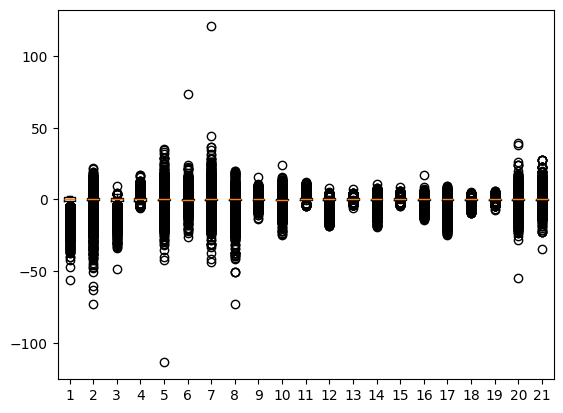

In [14]:
plt.boxplot(df[['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','V11','V12','V13','V14','V15','V16','V17','V18','V19','V20','V21']])
plt.show()

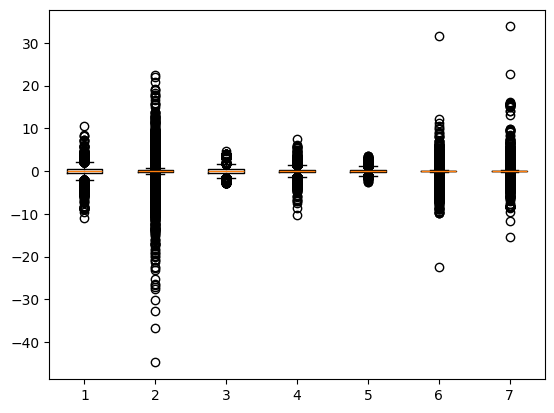

In [15]:
plt.boxplot(df[['V22','V23','V24','V25','V26','V27','V28']])
plt.show()

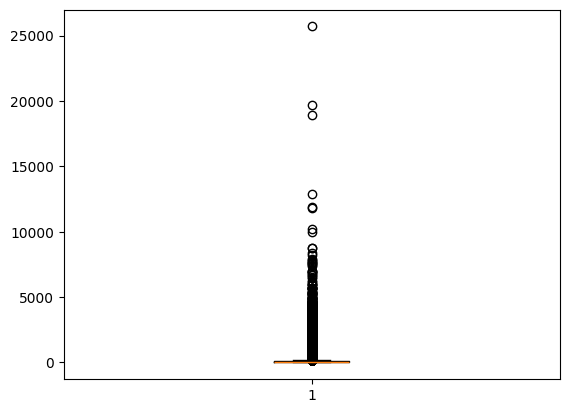

In [17]:
plt.boxplot(df['Amount'])
plt.show()

In [20]:
q3=df['Amount'].quantile(0.75)
q1=df['Amount'].quantile(0.25)
iqr=q3-q1
df['Amount']=q3-iqr*1.5
df['Amount']=q1-iqr*1.5


q3=df['V1'].quantile(0.75)
q1=df['V1'].quantile(0.25)
iqr=q3-q1
df['V1']=q3-iqr*1.5
df['V1']=q1-iqr*1.5

q3=df['V2'].quantile(0.75)
q1=df['V2'].quantile(0.25)
iqr=q3-q1
df['V2']=q3-iqr*1.5
df['V2']=q1-iqr*1.5

q3=df['V3'].quantile(0.75)
q1=df['V3'].quantile(0.25)
iqr=q3-q1
df['V3']=q3-iqr*1.5
df['V3']=q1-iqr*1.5

q3=df['V5'].quantile(0.75)
q1=df['V5'].quantile(0.25)
iqr=q3-q1
df['V5']=q3-iqr*1.5
df['V5']=q1-iqr*1.5

q3=df['V6'].quantile(0.75)
q1=df['V6'].quantile(0.25)
iqr=q3-q1
df['V6']=q3-iqr*1.5
df['V6']=q1-iqr*1.5

q3=df['V7'].quantile(0.75)
q1=df['V7'].quantile(0.25)
iqr=q3-q1
df['V7']=q3-iqr*1.5
df['V7']=q1-iqr*1.5

q3=df['V8'].quantile(0.75)
q1=df['V8'].quantile(0.25)
iqr=q3-q1
df['V8']=q3-iqr*1.5
df['V8']=q1-iqr*1.5

q3=df['V9'].quantile(0.75)
q1=df['V9'].quantile(0.25)
iqr=q3-q1
df['V9']=q3-iqr*1.5
df['V9']=q1-iqr*1.5

q3=df['V10'].quantile(0.75)
q1=df['V10'].quantile(0.25)
iqr=q3-q1
df['V10']=q3-iqr*1.5
df['V10']=q1-iqr*1.5

q3=df['V16'].quantile(0.75)
q1=df['V16'].quantile(0.25)
iqr=q3-q1
df['V16']=q3-iqr*1.5
df['V16']=q1-iqr*1.5

q3=df['V20'].quantile(0.75)
q1=df['V20'].quantile(0.25)
iqr=q3-q1
df['V20']=q3-iqr*1.5
df['V20']=q1-iqr*1.5

q3=df['V21'].quantile(0.75)
q1=df['V21'].quantile(0.25)
iqr=q3-q1
df['V21']=q3-iqr*1.5
df['V21']=q1-iqr*1.5

q3=df['V22'].quantile(0.75)
q1=df['V22'].quantile(0.25)
iqr=q3-q1
df['V22']=q3-iqr*1.5
df['V22']=q1-iqr*1.5

q3=df['V23'].quantile(0.75)
q1=df['V23'].quantile(0.25)
iqr=q3-q1
df['V23']=q3-iqr*1.5
df['V23']=q1-iqr*1.5

q3=df['V25'].quantile(0.75)
q1=df['V25'].quantile(0.25)
iqr=q3-q1
df['V25']=q3-iqr*1.5
df['V25']=q1-iqr*1.5

q3=df['V27'].quantile(0.75)
q1=df['V27'].quantile(0.25)
iqr=q3-q1
df['V27']=q3-iqr*1.5
df['V27']=q1-iqr*1.5

q3=df['V28'].quantile(0.75)
q1=df['V28'].quantile(0.25)
iqr=q3-q1
df['V28']=q3-iqr*1.5
df['V28']=q1-iqr*1.5






In [32]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,NaN,NaN,NaN,-1.052602e-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.618187e-02,NaN,-4.140710e-02,NaN,NaN,NaN,-0.012323
V1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V4,-0.105260,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.584638e-16,NaN,-4.247268e-16,NaN,NaN,NaN,0.133447
V5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#  EDA
# i checked outliers on all variables and removed them by use of iqr method

In [23]:
x=df.drop(columns=df[['Time','Class']])

In [24]:
y=df['Class']

In [25]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
scaler.fit_transform(x_train)
scaler.transform(x_test)

array([[ 8.88178420e-16,  8.88178420e-16,  2.22044605e-15, ...,
         5.55111512e-17,  8.32667268e-17, -2.84217094e-14],
       [ 8.88178420e-16,  8.88178420e-16,  2.22044605e-15, ...,
         5.55111512e-17,  8.32667268e-17, -2.84217094e-14],
       [ 8.88178420e-16,  8.88178420e-16,  2.22044605e-15, ...,
         5.55111512e-17,  8.32667268e-17, -2.84217094e-14],
       ...,
       [ 8.88178420e-16,  8.88178420e-16,  2.22044605e-15, ...,
         5.55111512e-17,  8.32667268e-17, -2.84217094e-14],
       [ 8.88178420e-16,  8.88178420e-16,  2.22044605e-15, ...,
         5.55111512e-17,  8.32667268e-17, -2.84217094e-14],
       [ 8.88178420e-16,  8.88178420e-16,  2.22044605e-15, ...,
         5.55111512e-17,  8.32667268e-17, -2.84217094e-14]],
      shape=(85443, 29))

In [30]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

In [31]:
skf=StratifiedKFold(shuffle=True,n_splits=5,random_state=42)

In [45]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(class_weight='balanced',max_iter=1000)
scores=cross_val_score(lr,x,y,cv=skf)
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [46]:
y_pred=lr.predict(x_test)

In [56]:
from sklearn.metrics import classification_report,confusion_matrix

In [57]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85294
           1       0.82      0.72      0.76       149

    accuracy                           1.00     85443
   macro avg       0.91      0.86      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [58]:
print(confusion_matrix(y_test,y_pred))

[[85270    24]
 [   42   107]]


# the confusion matrix state that 85270 normal transactions correctly approved
# 24 legitimate customers blocked
# 107 fraud transactions sucessfully stopped
# 42 fraud transactions slipped

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
tree=DecisionTreeClassifier(criterion='entropy',class_weight='balanced')
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(tree,x,y,cv=skf)
tree.fit(x_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [53]:
y_pred=tree.predict(x_test)

In [59]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85294
           1       0.82      0.72      0.76       149

    accuracy                           1.00     85443
   macro avg       0.91      0.86      0.88     85443
weighted avg       1.00      1.00      1.00     85443

[[85270    24]
 [   42   107]]


# logistic regression catches 90% of all fraud and only 6%flagged are real meets the success criteria above recall over 80%
# decisiontree classifier catches 72% which does not pass the sucessful criteria
# the bank is supposed to use logistic regession classification model

In [60]:
from sklearn.metrics import roc_curve,roc_auc_score,auc

In [61]:
lr_proba=lr.predict_proba(x_test)[:,1]
tree_proba=tree.predict_proba(x_test)[:,1]

In [74]:
fpr_lr,tpr_lr ,threshold_lr=roc_curve(y_test,lr_proba)
fpr_tree,tpr_tree,threshold_tree=roc_curve(y_test,tree_proba)

In [75]:
auc_lr=roc_auc_score(y_test,lr_proba)
auc_tree=roc_auc_score(y_test,tree_proba)

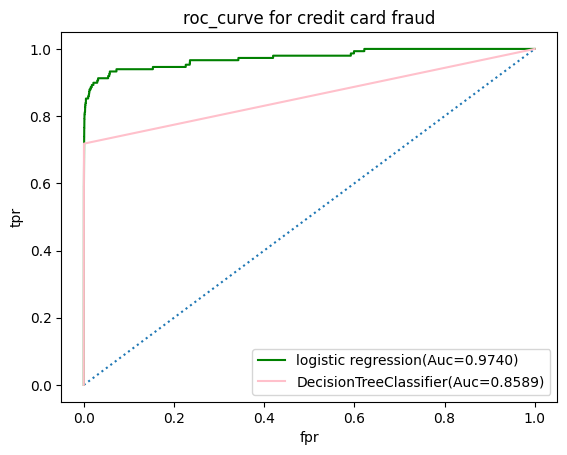

In [76]:
plt.plot([0,1],[0,1],linestyle='dotted')
plt.plot(fpr_lr,tpr_lr,label=f'logistic regression(Auc={auc_lr:.4f})',color='green')
plt.plot(fpr_tree,tpr_tree,label=f'DecisionTreeClassifier(Auc={auc_tree:.4f})',color='pink')
plt.title('roc_curve for credit card fraud')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.legend()
plt.show()

 # logistic regression is able to detect credit frauds alot better comp[ared to decision tree classifier

#CONCULSION

#FOR THIS CREDIT CARD FRAUD DATASET,LOGISTIC REGRESSION IS THE SUPERRIOR MODEL AND SHOULD BE PREFERREDCHOICE FOR DEPLOYMENT